In [2]:
from ocularrigidity.rigidity.features import compute_deltaY_masks
from pathlib import Path
from ocularrigidity.consts import ROOT_DATA_SMB
import numpy as np
from ocularrigidity.data.io import save_mask, load_mask
from ocularrigidity.segmentation.utils import get_choroid_segmentation_model
from ocularrigidity.segmentation.inference import infer
from ocularrigidity.data.compression import mp4_to_cube, read_gray
from ocularrigidity.data.io import load_cube

ModuleNotFoundError: No module named 'ocularrigidity.rigidity'

In [ ]:
# load the computed thicknesses
from matplotlib.pyplot import plot
import scipy
import numpy as np
from scipy.io import loadmat
from scipy.signal import lombscargle
import pandas as pd, csv

 
 
def load_time_vector(mat_path, struct_name="timeSeries"):
    """
    Parameters
    ----------
    mat_path : str
        Path to the .mat file.
    struct_name : str
        Name of the MATLAB struct (array) variable inside the file.
 
    Returns
    -------
    time : (N,) float64 ndarray
        Elapsed time in seconds, with the first sample at t = 0.
    """
    mat = loadmat(mat_path)
    if struct_name not in mat:
        available = [k for k in mat if not k.startswith("__")]
        raise KeyError(f"'{struct_name}' not found. Available variables: {available}")
 
    s = mat[struct_name].ravel()  # flatten the struct array to 1-D (length N)
 
    def field(name):
        # Each entry is a 1x1 array; take the scalar and force float64.
        # Casting to float is essential: hour/minute are stored as uint8,
        # so 3600*hour would overflow if left as an unsigned integer.
        return np.array([np.ravel(e)[0] for e in s[name]], dtype=np.float64)
 
    hour = field("hour")
    minute = field("minute")
    second = field("second")
 
    time = 3600.0 * hour + 60.0 * minute + second
    time = time - time.min()
    return time


path_condi = Path("E:/SANSORI/10_220215001/220215001before_rigidity/220215001before_rigidity_OD2")
path_deltaY = Path(path_condi / "RawImages" / "registeredBscans" / "deltaY.npz")
path_idx2keep = Path(path_condi / "RawImages" / "registeredBscans" / "detection_outliers_median_threshold.mat")
path_heartbeat = Path(path_condi / "Data Files" / "visit_data.csv")
path_timeseries = Path(path_condi / "RawImages" / "timeSeries.mat")
deltaY= np.load(path_deltaY)["deltaY"]

# import data
ids = scipy.io.loadmat(path_idx2keep)["idsFilteredMmi"].ravel()
df = pd.read_csv(path_heartbeat, quoting=csv.QUOTE_NONE)
hr = np.nanmean(pd.to_numeric(df["HR"], errors="coerce"))   # float64 scalaire, en BPM
band = (hr - 7, hr + 7) # BPM
AL = np.nanmean(pd.to_numeric(df["AL"], errors="coerce") )  # float ; cellules vides -> NaN
IOP = np.nanmean(pd.to_numeric(df["PascalIOP"], errors="coerce") ) # float ; cellules vides -> NaN
OPA = np.nanmean(pd.to_numeric(df["PascalOPA"], errors="coerce") ) # float ; cellules vides -> NaN
print(hr)
print(OPA)
print(IOP)
t = load_time_vector(path_timeseries)
t_filt = t[ids.astype(int) - 1]

pixYsize = 0.0039 #mm pix-1

# Define angular frequencies (rad/s)
frequencies = np.linspace(0.1, 5, 100)  # from 0 to 10 Hz with 0.1 Hz step
angular_frequencies = 2 * np.pi * frequencies  # from 0 to 10 Hz with 0.1 Hz step

59.0
3.7
14.6


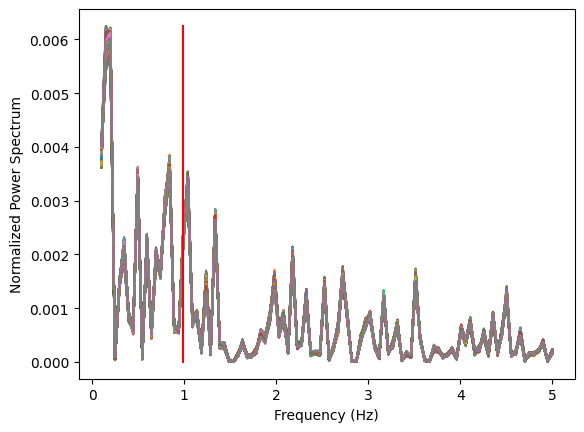

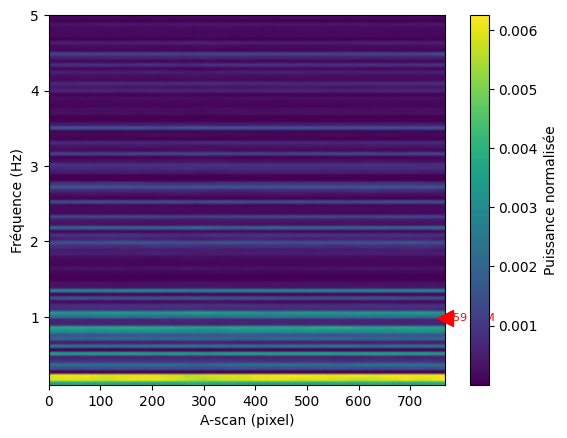

In [ ]:
from matplotlib import pyplot as plt 
# compute delta CT
power_scipy = np.zeros((len(frequencies), deltaY.shape[1]))
for iAscan in range(deltaY.shape[1]):
    deltaY_Ascan = deltaY[:,iAscan]
    norm = np.sqrt(np.sum(deltaY_Ascan ** 2))
    deltaY_norm = deltaY_Ascan/norm

    # Compute periodogram using SciPy
    power_scipy[:,iAscan] = lombscargle(t_filt, deltaY_norm, angular_frequencies)
    plt.plot(frequencies,power_scipy[:,iAscan])



plt.plot([hr/60, hr/60], [0, np.max(power_scipy)], color='r')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power Spectrum")

plt.figure()
im = plt.imshow(
    power_scipy,
    aspect='auto',
    origin='lower',
    extent=[0, power_scipy.shape[1], frequencies[0], frequencies[-1]],
    cmap='viridis',
)
plt.yticks(np.arange(0, 6, 1))
plt.ylabel("Fréquence (Hz)")
plt.xlabel("A-scan (pixel)")
plt.colorbar(im, label="Puissance normalisée")

# --- mise en valeur de la HR ---
xN = power_scipy.shape[1]
plt.plot(xN, hr/60, marker='<', color='red', ms=12,
         clip_on=False, zorder=5)              # flèche dans la marge droite
plt.text(xN*1.02, hr/60, f"{hr:.0f} BPM", color='red',
         va='center', fontsize=8)
plt.show()

In [ ]:
import numpy as np
from scipy.signal import butter, sosfiltfilt, hilbert, lombscargle
from scipy.integrate import cumulative_trapezoid
from matplotlib import pyplot as plt
from scipy.signal import medfilt   # ajoute à tes imports

def _weighted_median(v, w):
    o = np.argsort(v); v, w = v[o], w[o]
    cw = np.cumsum(w)
    if cw[-1] <= 0:
        return np.nan
    return v[np.searchsorted(cw, 0.5*cw[-1])]

# === MÉTHODE 1 : passe-bande FIXE + Hilbert (enveloppe ET fréquence inst.) ===
def method1_bandpass_hilbert(ts, dY, band_hz, fc, oversample=20, order=4, edge=0.05):
    lo, hi = band_hz
    fs = oversample * fc
    if hi >= fs / 2:
        raise ValueError("highcut >= Nyquist : augmente oversample")
    t_uni = np.linspace(ts[0], ts[-1], int(np.ceil((ts[-1]-ts[0])*fs)) + 1)
    sos = butter(order, [lo, hi], btype='band', fs=fs, output='sos')
    A = np.zeros((t_uni.size, dY.shape[1]))
    F = np.zeros((t_uni.size, dY.shape[1]))
    S = np.zeros((t_uni.size, dY.shape[1]))                  # signal filtré (passe-bande)
    for i in range(dY.shape[1]):
        bp = sosfiltfilt(sos, np.interp(t_uni, ts, dY[:, i]))
        z  = hilbert(bp)
        S[:, i] = bp
        A[:, i] = np.abs(z)
        F[:, i] = np.gradient(np.unwrap(np.angle(z)), t_uni) / (2*np.pi)

    f_hil = np.array([_weighted_median(F[k], A[k]) for k in range(t_uni.size)])
    good = np.isfinite(f_hil)
    if good.sum() > 1:
        f_hil = np.interp(np.arange(f_hil.size), np.flatnonzero(good), f_hil[good])
    win = int(round(fs / fc)) | 1
    f_hil = medfilt(f_hil, win)

    m = int(edge * t_uni.size)
    return t_uni[m:-m], A[m:-m], f_hil[m:-m], S[m:-m]        # <-- + S

# === MÉTHODE 2a : fréquence cardiaque instantanée HR(t) =====================
from scipy.signal import find_peaks   # ajoute à tes imports

def instantaneous_freq(ts, dY, band_hz, n_cycles=8.0, n_grid=200, search_pad=0.5,
                       f_ref=None, prominence_k=1.0,
                       min_snr=3.0, deg=3, k=2.5, n_iter=5):
    lo, hi = band_hz; fc = 0.5*(lo+hi)
    if f_ref is None:
        f_ref = fc                                   # fréquence HR mesurée = centre de bande
    fgrid = np.linspace(max((1-search_pad)*lo, 0.03), (1+search_pad)*hi, n_grid)
    wgrid = 2*np.pi*fgrid
    win = n_cycles / fc
    centers = np.arange(ts[0]+win/2, ts[-1]-win/2, win/n_cycles)   # fenêtres chevauchantes
    f_inst = np.full(centers.size, np.nan)
    snr    = np.zeros(centers.size)

    for j, tc in enumerate(centers):
        sel = np.abs(ts - tc) <= win/2
        if sel.sum() < 8:
            continue
        tw = ts[sel]
        specs = []
        for i in range(dY.shape[1]):
            seg = dY[sel, i] - dY[sel, i].mean()
            P = lombscargle(tw, seg, wgrid)
            s = P.sum()
            if s > 0:
                specs.append(P / s)
        if not specs:
            continue
        P_med = np.median(specs, axis=0)
        floor = np.median(P_med)

        # find_peaks : maxima LOCAUX réels (ignore les bords de grille = anciens rails)
        pk, _ = find_peaks(P_med, prominence=prominence_k*floor)
        if pk.size == 0:
            continue                                  # aucun pic franc -> fenêtre laissée NaN
        # parmi les pics réels, celui le plus proche de la HR mesurée
        jbest = pk[np.argmin(np.abs(fgrid[pk] - f_ref))]
        f_inst[j] = fgrid[jbest]
        snr[j]    = P_med[jbest] / (floor + 1e-12)

    finite = np.isfinite(f_inst)
    if finite.sum() < deg + 2:
        raise RuntimeError(f"Trop peu de fenêtres exploitables ({finite.sum()}). "
                           f"Baisse prominence_k ou n_cycles.")

    # seuil SNR adaptatif (jamais au point de tout rejeter)
    thr = min(min_snr, np.percentile(snr[finite], 10))
    ok  = finite & (snr >= thr)
    if ok.sum() < deg + 2:
        ok = finite.copy()

    # clipping itératif contre la tendance, borné pour ne pas sur-élaguer
    min_keep = deg + 2
    for _ in range(n_iter):
        if ok.sum() <= min_keep:
            break
        cf    = np.polyfit(centers[ok], f_inst[ok], min(deg, ok.sum()-1))
        resid = f_inst - np.polyval(cf, centers)
        r0    = np.median(resid[ok])
        sig   = 1.4826 * np.median(np.abs(resid[ok] - r0)) + 1e-12
        new_ok = ok & (np.abs(resid - r0) <= k * sig)
        if new_ok.sum() < min_keep or np.array_equal(new_ok, ok):
            break
        ok = new_ok

    if ok.sum() < deg + 1:
        ok = finite.copy()
    print(f"[instantaneous_freq] fenêtres : {finite.sum()} finies "
          f"-> {ok.sum()} retenues (seuil SNR={thr:.2f})")

    cf  = np.polyfit(centers[ok], f_inst[ok], min(deg, max(0, ok.sum()-1)))
    tg  = np.linspace(ts[0], ts[-1], 2000)
    f_t = np.clip(np.polyval(cf, tg), fgrid[0], fgrid[-1])
    return centers, f_inst, tg, f_t, ok

# === MÉTHODE 2b : démodulation à phase verrouillée + moyenne locale =========
def method2_demod(ts, dY, tg, f_t, fc, kernel_cycles=1.0, n_out=300, edge=0.05):
    phi_cum = 2*np.pi*cumulative_trapezoid(f_t, tg, initial=0.0)
    phi     = np.interp(ts,   tg, phi_cum)
    phi_out = np.interp(np.linspace(ts[0], ts[-1], n_out), tg, phi_cum)  # phase sur grille sortie
    sigma   = (kernel_cycles / fc) / 2.355
    tout    = np.linspace(ts[0], ts[-1], n_out)
    A = np.zeros((tout.size, dY.shape[1]))
    S = np.zeros((tout.size, dY.shape[1]))                  # signal reconstruit band-limité
    for i in range(dY.shape[1]):
        z = dY[:, i] * np.exp(-1j*phi)
        for kk, tc in enumerate(tout):
            w  = np.exp(-0.5*((ts - tc)/sigma)**2)
            zc = np.sum(w*z) / np.sum(w)                    # moyenne locale COMPLEXE
            A[kk, i] = 2.0 * np.abs(zc)                     # amplitude crête (= a)
            S[kk, i] = 2.0 * np.real(zc * np.exp(1j*phi_out[kk]))   # signal reconstruit
    m = int(edge * tout.size)
    return tout[m:-m], A[m:-m], S[m:-m]               # <-- + S

N=368, n_ascan=768, T=56.4s, ~55.4 cycles
[instantaneous_freq] fenêtres : 46 finies -> 41 retenues (seuil SNR=1.96)


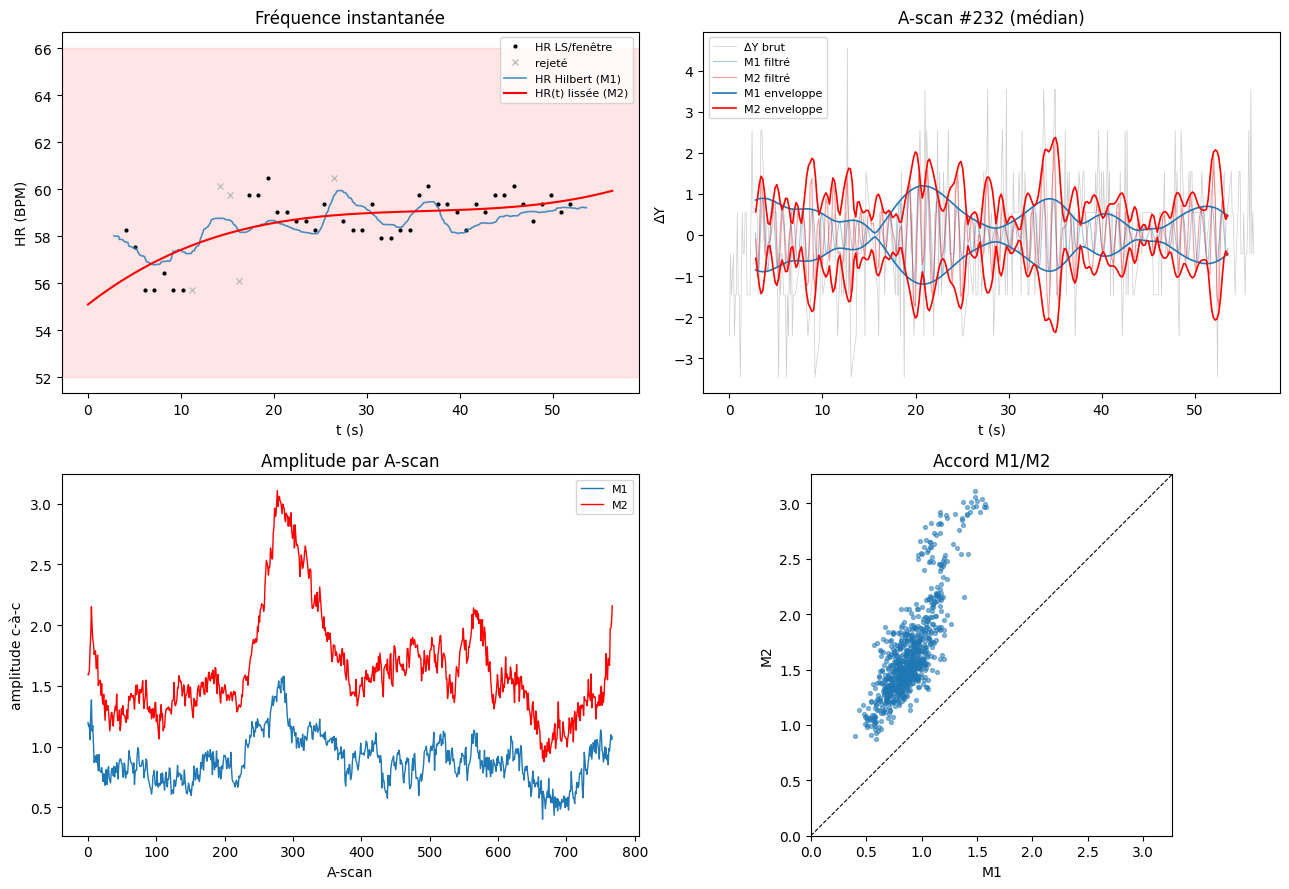

fenêtres retenues : 41/48
corrélation M1/M2 : r = 0.810
ratio médian M2/M1 : 1.816
dérive HR (LS retenue) : 56 -> 60 BPM


In [ ]:
# --- préparation (entrées : deltaY, t_filt, band en BPM) ---
flo, fhi = band[0] / 60.0, band[1] / 60.0
fc0 = 0.5 * (flo + fhi)
order_sort = np.argsort(t_filt)
ts = t_filt[order_sort]
dY = deltaY[order_sort] - deltaY[order_sort].mean(0)
N, n_ascan = dY.shape
print(f"N={N}, n_ascan={n_ascan}, T={ts[-1]-ts[0]:.1f}s, ~{(ts[-1]-ts[0])*fc0:.1f} cycles")

# --- exécution des deux méthodes ---
t1, A1, f_hil, S1 = method1_bandpass_hilbert(ts, dY, (flo, fhi), fc0)   # <-- 4 sorties
centers, f_inst, tg, f_t, ok = instantaneous_freq(ts, dY, (flo, fhi))
t2, A2, S2 = method2_demod(ts, dY, t1, f_hil, fc0)                        # <-- 3 sorties

# --- grille commune + scalaire crête-à-crête par A-scan ---
tcg = np.linspace(max(t1[0], t2[0]), min(t1[-1], t2[-1]), 250)
A1c = np.array([np.interp(ts, t1, A1[:, i]) for i in range(n_ascan)]).T
A2c = np.array([np.interp(ts, t2, A2[:, i]) for i in range(n_ascan)]).T
amp1, amp2 = 2*np.median(A1c, 0), 2*np.median(A2c, 0)

# --- figure ---
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) fréquence instantanée
ax[0,0].plot(centers[ok],  f_inst[ok]*60,  'k.', ms=4, label="HR LS/fenêtre")
ax[0,0].plot(centers[~ok], f_inst[~ok]*60, 'x', color='0.75', ms=5, label="rejeté")
ax[0,0].plot(t1, f_hil*60, color='C0', lw=1.2, alpha=0.8, label="HR Hilbert (M1)")
ax[0,0].plot(tg, f_t*60, 'r-', lw=1.5, label="HR(t) lissée (M2)")
ax[0,0].axhspan(band[0], band[1], color='red', alpha=0.1)
ax[0,0].set(xlabel="t (s)", ylabel="HR (BPM)", title="Fréquence instantanée")
ax[0,0].legend(fontsize=8)

# (b) A-scan médian : brut + signaux filtrés (transparents) + enveloppes (opaques)
imed = np.argsort(amp2)[len(amp2)//2]
ax[0,1].plot(ts, dY[:, imed], color='0.8', lw=0.5, label="ΔY brut")
# signaux filtrés band-limités -> plus transparents que les amplitudes
ax[0,1].plot(t1, S1[:, imed], color='C0', lw=0.8, alpha=0.4, label="M1 filtré")
ax[0,1].plot(t2, S2[:, imed], color='r',  lw=0.8, alpha=0.4, label="M2 filtré")
# enveloppes ±A (amplitude crête) -> opaques
ax[0,1].plot(t1,  A1[:, imed], color='C0', lw=1.2, label="M1 enveloppe")
ax[0,1].plot(t1, -A1[:, imed], color='C0', lw=1.2)
ax[0,1].plot(t2,  A2[:, imed], color='r',  lw=1.2, label="M2 enveloppe")
ax[0,1].plot(t2, -A2[:, imed], color='r',  lw=1.2)
ax[0,1].set(xlabel="t (s)", ylabel="ΔY", title=f"A-scan #{imed} (médian)")
ax[0,1].legend(fontsize=8)

# (c) amplitude par A-scan
x = np.arange(n_ascan)
ax[1,0].plot(x, amp1, 'C0', lw=1, label="M1")
ax[1,0].plot(x, amp2, 'r',  lw=1, label="M2")
ax[1,0].set(xlabel="A-scan", ylabel="amplitude c-à-c", title="Amplitude par A-scan")
ax[1,0].legend(fontsize=8)

# (d) accord M1 vs M2
lim = [0, max(amp1.max(), amp2.max())*1.05]
ax[1,1].plot(lim, lim, 'k--', lw=0.8)
ax[1,1].scatter(amp1, amp2, s=8, alpha=0.5)
ax[1,1].set(xlabel="M1", ylabel="M2", title="Accord M1/M2", xlim=lim, ylim=lim)
ax[1,1].set_aspect('equal')

plt.tight_layout(); plt.show()

# --- métriques ---
print(f"fenêtres retenues : {ok.sum()}/{ok.size}")
print(f"corrélation M1/M2 : r = {np.corrcoef(amp1, amp2)[0,1]:.3f}")
print(f"ratio médian M2/M1 : {np.median(amp2/amp1):.3f}")
print(f"dérive HR (LS retenue) : {np.nanmin(f_inst[ok])*60:.0f} -> {np.nanmax(f_inst[ok])*60:.0f} BPM")

In [ ]:
# rigidity calculation
deltaCT = np.median(amp1)*pixYsize # mm
CT = np.median(deltaY)*pixYsize # mm

# from sayah et al. 2020
AL_adj = AL*0.87
R = AL_adj + CT

# deltaCTeq = 0.5*deltaCT* np.sqrt(R**2 - (0.5*deltaCT*np.sin(alpha))**2) + np.cos(alpha) # mm
# CTeq = 0.5*CT*np.cos(alpha) + np.sqrt(R**2 - (0.5*CT*np.sin(alpha))**2) - r # mm
 
IOP_IOP0 = (IOP+OPA) / IOP # mmHg/mmHg

# ΔV ≅π/2(AL_adj + CT)^2 (ΔCT)

deltaV = np.pi/2 * (AL_adj + CT)**2 * deltaCT #mm^3

k = np.log(IOP_IOP0) / deltaV # mm^-3

print(f"AL : {AL} mm")
print(f"CT : {CT} mm")
print(f"delta CT : {deltaCT} mm")
print(f"delta V : {deltaV} mm^3")
print(f"k : {k} mm^-3")

AL : 23.3 mm
CT : 0.2768999934196472 mm
delta CT : 0.0033992200811320075 mm
delta V : 2.254415944953863 mm^3
k : 0.10019425724817044 mm^-3
